In [8]:
import pandas as pd 
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import scipy.stats as stats

In [13]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\MLR_ASSIGNMENT\insurance (1).csv")

In [14]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(1)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


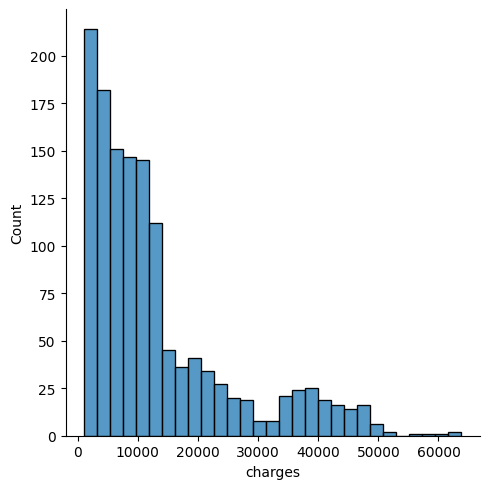

In [22]:
sns.displot(df['charges'])
plt.show()

In [23]:
df['sex']=df['sex'].map({"female":0,"male":1})
df['smoker']=df['smoker'].str.lower().map({'yes':1,'no':0})

In [24]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [25]:
df_region=pd.get_dummies(df['region'],dtype=int,drop_first=True)

In [26]:
df_region

,northwest,southeast,southwest
0,0,0,1
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
1333,1,0,0
1334,0,0,0
1335,0,1,0
1336,0,0,1


In [27]:
df_ori=pd.concat([df,df_region],axis=1).drop('region',axis=1)

In [28]:
df_ori

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


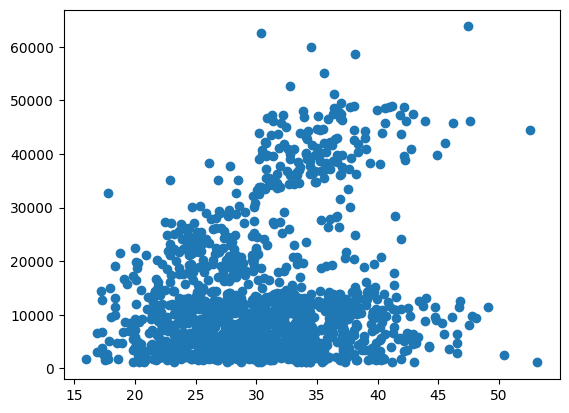

In [29]:
plt.scatter(df_ori['bmi'],df_ori['charges'])
plt.show()

In [30]:
df['bmi'].corr(df['charges'])

np.float64(0.19840083122624938)

<Axes: xlabel='smoker', ylabel='charges'>

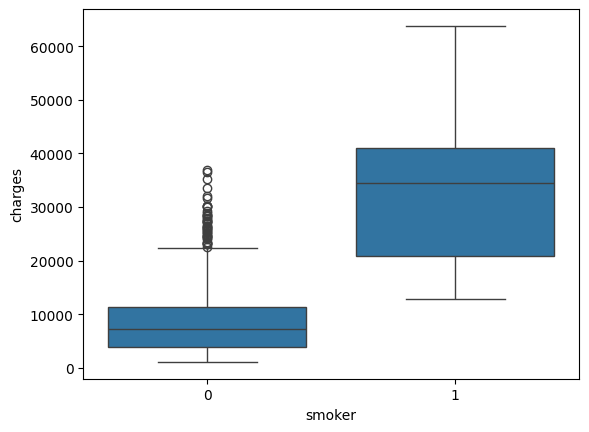

In [31]:
sns.boxplot(data=df_ori,x='smoker',y='charges')

(array([535., 398., 129.,  86.,  35.,  59.,  57.,  32.,   2.,   4.]),
 array([ 1121.8739  ,  7386.729311, 13651.584722, 19916.440133,
        26181.295544, 32446.150955, 38711.006366, 44975.861777,
        51240.717188, 57505.572599, 63770.42801 ]),
 <BarContainer object of 10 artists>)

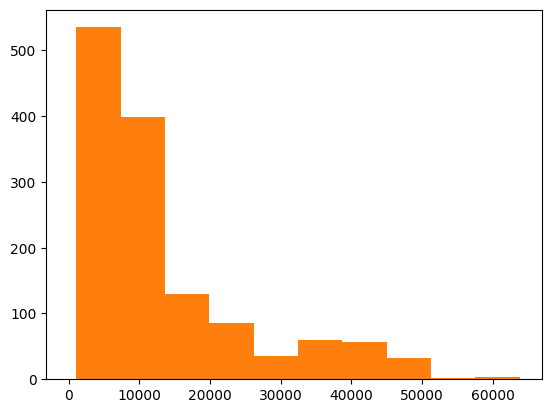

In [33]:
plt.hist(df['age'])
plt.hist(df['charges'])

In [34]:
df_ori.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest'],
      dtype='object')

In [35]:
x=df_ori.loc[:,['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest']]
y=df_ori['charges']

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [37]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
# 4. Predict on test set
y_pred=lr.predict(x_test)

In [40]:
# 5. Evaluate the model
r2_score(y_test,y_pred)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [42]:
# 6. Display coefficients and intercept
cofficient=pd.DataFrame({'feature':x.columns,'cofficient':lr.coef_})
print("Model Cofficient :\n",cofficient)
print("Intercept :",lr.intercept_)

Model Cofficient :
      feature    cofficient
0        age  1.057136e-15
1        sex  6.942558e-12
2        bmi  7.655253e-14
3   children -5.484063e-14
4     smoker  8.358776e-12
5    charges  1.000000e+00
6  northwest -1.021357e-13
7  southeast  8.540318e-14
8  southwest  4.897911e-13
Intercept : 0.0


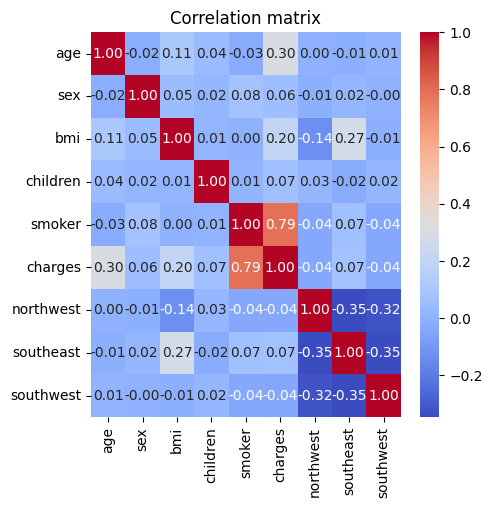

In [52]:
# 1. Check for multicollinearity using correlation matrix
plt.figure(figsize=(5,5))
sns.heatmap(df_ori.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [50]:
# 2. Feature Scaling (optional)
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)

In [51]:

# Train-test split again with scaled features
x_train_s,x_test_s,y_train_s,y_test_s=train_test_split(x_scale,y,test_size=0.2,random_state=42)
model_scale=LinearRegression()
model_scale.fit(x_train_s,y_train_s)
y_pred_s=model_scale.predict(x_test_s)

r2_s=r2_score(y_test_s,y_pred_s)
print(f"R-square after scalling:{r2_s:.4f}")

R-square after scalling:1.0000
